In [ ]:
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import rasterio as rio
import rasterio.mask as rio_mask
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [59]:
data_path = Path(os.environ["DATA_PATH"])

In [113]:
bin_map = {
    1: "1 - Muy frío",
    2: "2 - Frío",
    3: "3 - Ligeramente frío",
    4: "4 - Templado",
    5: "5 - Ligeramente cálido",
    6: "6 - Cálido",
    7: "7 - Muy cálido",
}

In [114]:
bounds = gpd.read_file(data_path / "lim_aumxl24")

In [129]:
df = (
    gpd.read_file(data_path / "USOS_DE_SUELO_EXITS_24")
    .filter(["USOSUELO24", "geometry"])
    .assign(geometry=lambda df: df["geometry"].force_2d())
    .assign(geometry=lambda df: df["geometry"].centroid)
)


out = []
with rio.open("./temp_day_night.tif") as ds:
    data, _ = rio_mask.mask(ds, [bounds.to_crs(ds.crs)["geometry"].item()], crop=True, nodata=np.nan)
    data = data[0]

    mu = np.nanmean(data)
    std = np.nanstd(data)

    bins = [
        -np.inf,
        mu - 2.5 * std,
        mu - 1.5 * std,
        mu - 0.5 * std,
        mu + 0.5 * std,
        mu + 1.5 * std,
        mu + 2.5 * std,
        np.inf,
    ]

    df = df.to_crs(ds.crs)
    for idx, geom in df["geometry"].items():
        masked, _ = rio_mask.mask(ds, [geom], crop=True)

        temp_day = masked[0].squeeze().item()
        temp_night = masked[1].squeeze().item()

        out.append(
            {
                "idx": idx,
                "temp_day": temp_day,
                "temp_night": temp_night,
                "bin_day": bin_map[np.digitize(temp_day, bins)],
            },
        )

df_temp = pd.DataFrame(out).set_index("idx")
df = df.join(df_temp)

In [146]:
grouped = df.groupby("USOSUELO24").agg({"temp_day": "mean", "temp_night": "mean"})

grouped_bins = (
    df.groupby(["USOSUELO24", "bin_day"])
    .size()
    .unstack(fill_value=0)
    # .filter(["4 - Templado", "5 - Ligeramente cálido", "6 - Cálido", "7 - Muy cálido"])
)
grouped_bins = grouped_bins.div(grouped_bins.sum(axis=1), axis=0).sort_values("5 - Ligeramente cálido", ascending=False)

/var/folders/yq/0mz24vy927s9m5vjh6gqb6040000gn/T/ipykernel_38367/3274123527.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdBu_r', n_bins)


<Axes: ylabel='USOSUELO24'>

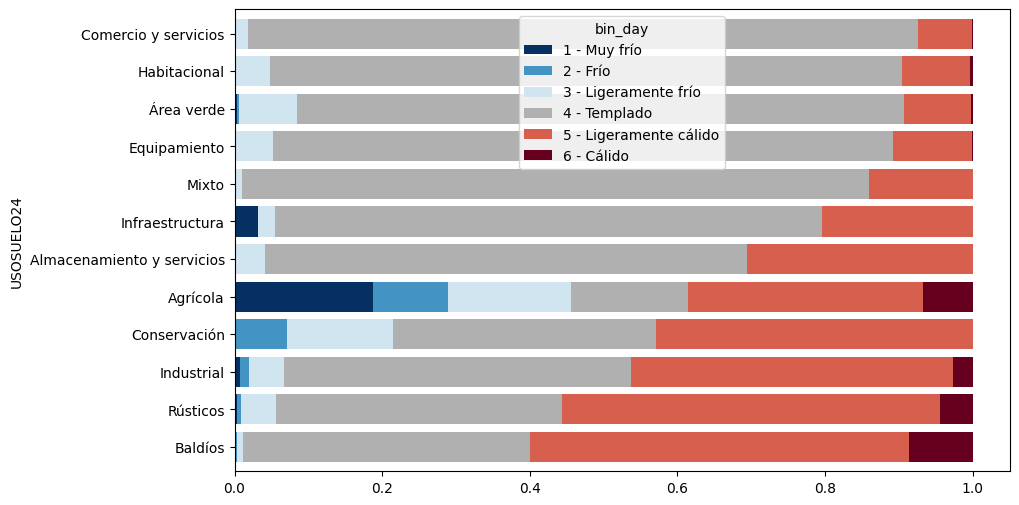

In [152]:
n_bins = len(grouped_bins.columns)
cmap = cm.get_cmap('RdBu_r', n_bins)
cmap_list = [mcolors.rgb2hex(cmap(i)) for i in range(n_bins)]

# Replace color for '4 - Templado' with gray if present
col_labels = list(grouped_bins.columns)
if '4 - Templado' in col_labels:
    idx = col_labels.index('4 - Templado')
    cmap_list[idx] = '#b0b0b0'  # gray

fig, ax = plt.subplots(figsize=(10, 6))
grouped_bins.plot.barh(stacked=True, color=cmap_list, width=0.8, ax=ax)

In [155]:
grouped_bins.to_csv("temp_grouped.csv", index=True)
df.groupby("USOSUELO24")["temp_day"].mean().sort_values().to_csv("temp_day.csv", index=True)

/var/folders/yq/0mz24vy927s9m5vjh6gqb6040000gn/T/ipykernel_38367/36550131.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0, 0.5, '')

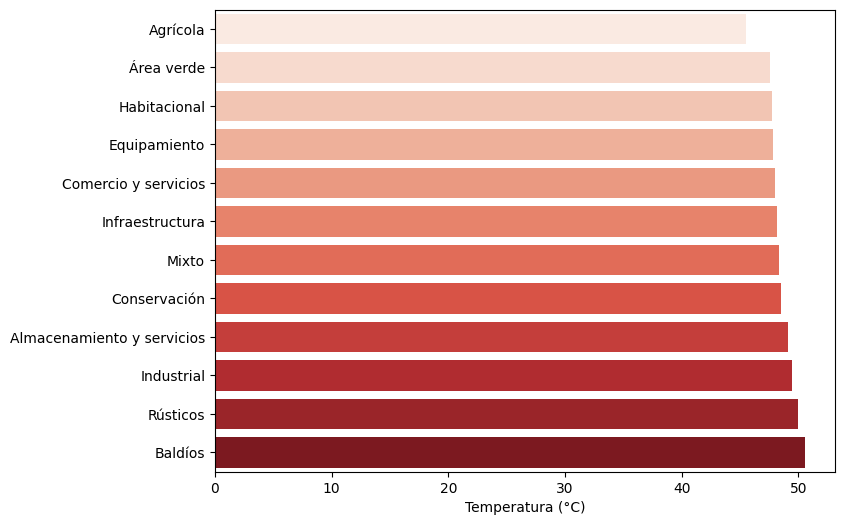

In [149]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(
    df.groupby("USOSUELO24")["temp_day"].mean().sort_values(),
    palette="Reds",
    orient="h",
    ax=ax,
)
ax.set_xlabel("Temperatura (°C)")
ax.set_ylabel("")

In [ ]:
df = df.assign(category=pd.Series(out)).assign(
    category=lambda df: df["category"].map(
        {3: "0 - Templado", 4: "1 - Ligeramente caliente", 5: "2 - Caliente"},
    ),
)

In [ ]:
test = (
    df.groupby(["USOSUELO24", "category"])["geometry"]
    .count()
    .reset_index()
    .pivot_table(
        index="USOSUELO24",
        columns="category",
        values="geometry",
        fill_value=0,
    )
)
test = test.div(test.sum(axis=1), axis=0).sort_index(ascending=False)

(0.0, 1.0)

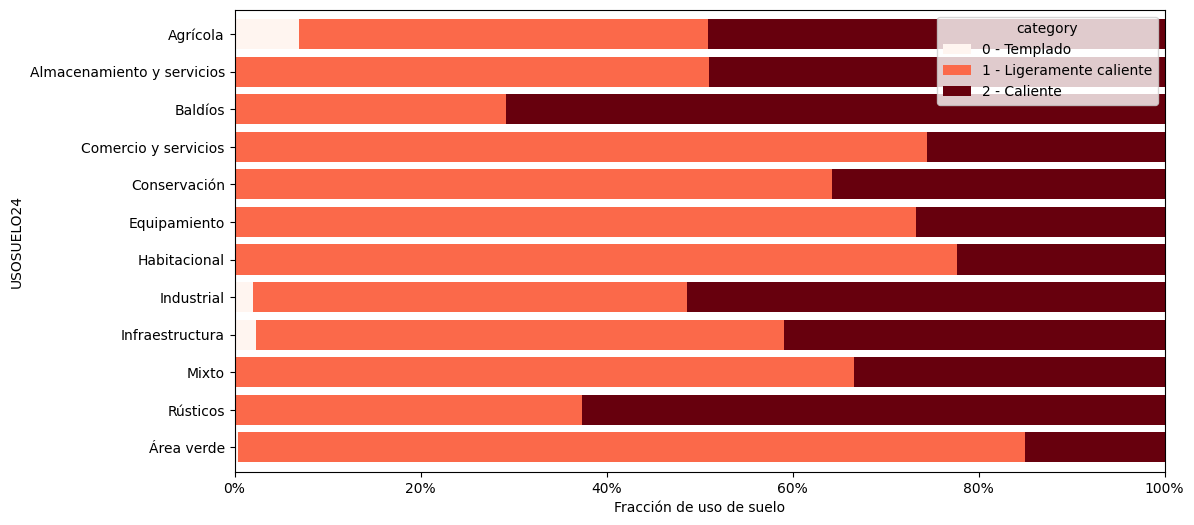

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
test.plot.barh(stacked=True, cmap="Reds", ax=ax, width=0.8)
ax.set_xlabel("Fracción de uso de suelo")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.set_xlim(0, 1)